In [1]:
import h5py as h5
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.models as models
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os
import csv
import h5py
from torchvision.models import resnet18
from torch.optim.lr_scheduler import StepLR
from tqdm import tqdm
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from datasets import load_dataset
from PIL import Image
device = 'cuda' if torch.cuda.is_available() else 'cpu'
import warnings 
warnings.filterwarnings("ignore")

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.5 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
data = h5py.File('/kaggle/input/rotated-mnist-dataset/mnist_rotated_pair.h5', 'r')

In [7]:
class VAE(nn.Module):
    def __init__(self, latent_dim=64):
        super(VAE, self).__init__()
        resnet = models.resnet18(pretrained=True)
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
        resnet.maxpool = nn.Identity() 
        self.encoder = nn.Sequential(
            resnet.conv1,   
            resnet.bn1,
            resnet.relu,
            resnet.layer1,  
            resnet.layer2,  
            resnet.layer3,  
            resnet.layer4,  
            resnet.avgpool, 
            nn.Flatten()    
        )
        self.fc_mu = nn.Linear(512, latent_dim)
        self.fc_logvar = nn.Linear(512, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, 64 * 7 * 7)
        
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 7, 7)),  
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),  
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),  
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), 
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),  
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), 
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1), 
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()
        )
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        h_decode = self.fc_decode(z)
        x_recon = self.decoder(h_decode)
        return x_recon, mu, logvar

In [8]:
model = VAE(latent_dim = 2).to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s]


In [14]:
model.load_state_dict(torch.load('/kaggle/input/vae/pytorch/default/1/VAE.pth', weights_only = True)['model_state_dict'])

<All keys matched successfully>

In [15]:
train_filename = 'data_train.h5'
val_filename = 'data_val.h5'

rotations_per_instance = 12

images = data['rotated_images'][:]  
labels = data['labels'][:]          

total_samples = images.shape[0]
num_instances = total_samples // rotations_per_instance

instance_labels = []
for i in range(num_instances):
    instance_label = labels[i * rotations_per_instance]
    instance_labels.append(instance_label)
instance_labels = np.array(instance_labels)

instances_label1 = np.where(instance_labels == 1)[0]
instances_label2 = np.where(instance_labels == 2)[0]

np.random.shuffle(instances_label1)
np.random.shuffle(instances_label2)

def split_indices(instances, split_ratio=0.9):
    split_idx = int(len(instances) * split_ratio)
    return instances[:split_idx], instances[split_idx:]

train_label1, val_label1 = split_indices(instances_label1)
train_label2, val_label2 = split_indices(instances_label2)

train_instances = np.concatenate([train_label1, train_label2])
val_instances = np.concatenate([val_label1, val_label2])

train_instances = np.sort(train_instances)
val_instances = np.sort(val_instances)

def get_sample_indices(instances, rotations_per_instance):
    sample_indices = []
    for inst in instances:
        start = inst * rotations_per_instance
        end = start + rotations_per_instance
        sample_indices.extend(range(start, end))
    return np.array(sample_indices)

train_indices = get_sample_indices(train_instances, rotations_per_instance)
val_indices = get_sample_indices(val_instances, rotations_per_instance)

with h5py.File(train_filename, 'w') as f_train:
    f_train.create_dataset('rotated_images', data=images[train_indices])
    f_train.create_dataset('labels', data=labels[train_indices])

with h5py.File(val_filename, 'w') as f_val:
    f_val.create_dataset('rotated_images', data=images[val_indices])
    f_val.create_dataset('labels', data=labels[val_indices])

print(f"Created training file '{train_filename}' with {len(train_indices)} samples.")
print(f"Created validation file '{val_filename}' with {len(val_indices)} samples.")

Created training file 'data_train.h5' with 160560 samples.
Created validation file 'data_val.h5' with 17844 samples.


In [16]:
train_mlp_data = h5py.File('data_train.h5','r')
val_mlp_data = h5py.File('data_val.h5','r')

In [17]:
class RotationPairDataset():
    def __init__(self, hdf5_file, rotations_per_instance=12):
        self.hdf5_file = hdf5_file
        self.images = self.hdf5_file['rotated_images']  
        self.rotations_per_instance = rotations_per_instance
        self.total_samples = self.images.shape[0]
        self.num_instances = self.total_samples // self.rotations_per_instance
        self.num_pairs = self.num_instances * (self.rotations_per_instance - 1)

    def __len__(self):
        return self.num_pairs

    def __getitem__(self, idx):
        instance = idx // (self.rotations_per_instance - 1)
        pair_idx = idx % (self.rotations_per_instance - 1)
        
        idx_source = instance * self.rotations_per_instance + pair_idx
        idx_target = instance * self.rotations_per_instance + pair_idx + 1
        
        img_source = self.images[idx_source]
        img_target = self.images[idx_target]
        label = self.hdf5_file['labels'][idx_target]
        
        angle_source = pair_idx * 30
        
        img_source = torch.tensor(img_source, dtype=torch.float32)
        img_target = torch.tensor(img_target, dtype=torch.float32)

        if img_source.ndim == 2:
            img_source = img_source.unsqueeze(0)
            img_target = img_target.unsqueeze(0)
        
        return img_source, img_target, angle_source, label

In [18]:
mlp_train_dataset = RotationPairDataset(train_mlp_data, rotations_per_instance=12)
mlp_train_dataloader = DataLoader(mlp_train_dataset, batch_size=64, shuffle=True)

In [19]:
mlp_val_dataset = RotationPairDataset(val_mlp_data, rotations_per_instance=12)
mlp_val_dataloader = DataLoader(mlp_val_dataset, batch_size=8, shuffle=False)

In [20]:
class MLP(nn.Module):
    def __init__(self, latent_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        
    def forward(self, z):
        return self.model(z)

latent_dim = 2  
mlp = MLP(latent_dim).to(device)
optimizer_mlp = optim.Adam(mlp.parameters(), lr=1e-3)
criterion = nn.MSELoss()

model.encoder.eval()
for param in model.encoder.parameters():
    param.requires_grad = False

num_epochs = 5
for epoch in range(num_epochs):
    mlp.train()
    running_loss = 0.0
    for img, img_30, _, _ in tqdm(mlp_train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        img = img.to(device).float() / 255.0
        img_30 = img_30.to(device).float() / 255.0
        
        with torch.no_grad():
            _, z, _ = model(img)
            _, z_30, _ = model(img_30)
        
        z_pred = mlp(z)
        
        loss = criterion(z_pred, z_30)
        
        optimizer_mlp.zero_grad()
        loss.backward()
        optimizer_mlp.step()
        running_loss += loss.item()
    
    avg_loss = running_loss / len(mlp_train_dataloader)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")

Epoch 1/5: 100%|██████████| 2300/2300 [01:20<00:00, 28.51it/s]


Epoch 1/5 - Loss: 0.0684


Epoch 2/5: 100%|██████████| 2300/2300 [01:19<00:00, 29.04it/s]


Epoch 2/5 - Loss: 0.0355


Epoch 3/5: 100%|██████████| 2300/2300 [01:19<00:00, 29.08it/s]


Epoch 3/5 - Loss: 0.0329


Epoch 4/5: 100%|██████████| 2300/2300 [01:15<00:00, 30.33it/s]


Epoch 4/5 - Loss: 0.0319


Epoch 5/5: 100%|██████████| 2300/2300 [01:14<00:00, 30.91it/s]

Epoch 5/5 - Loss: 0.0314


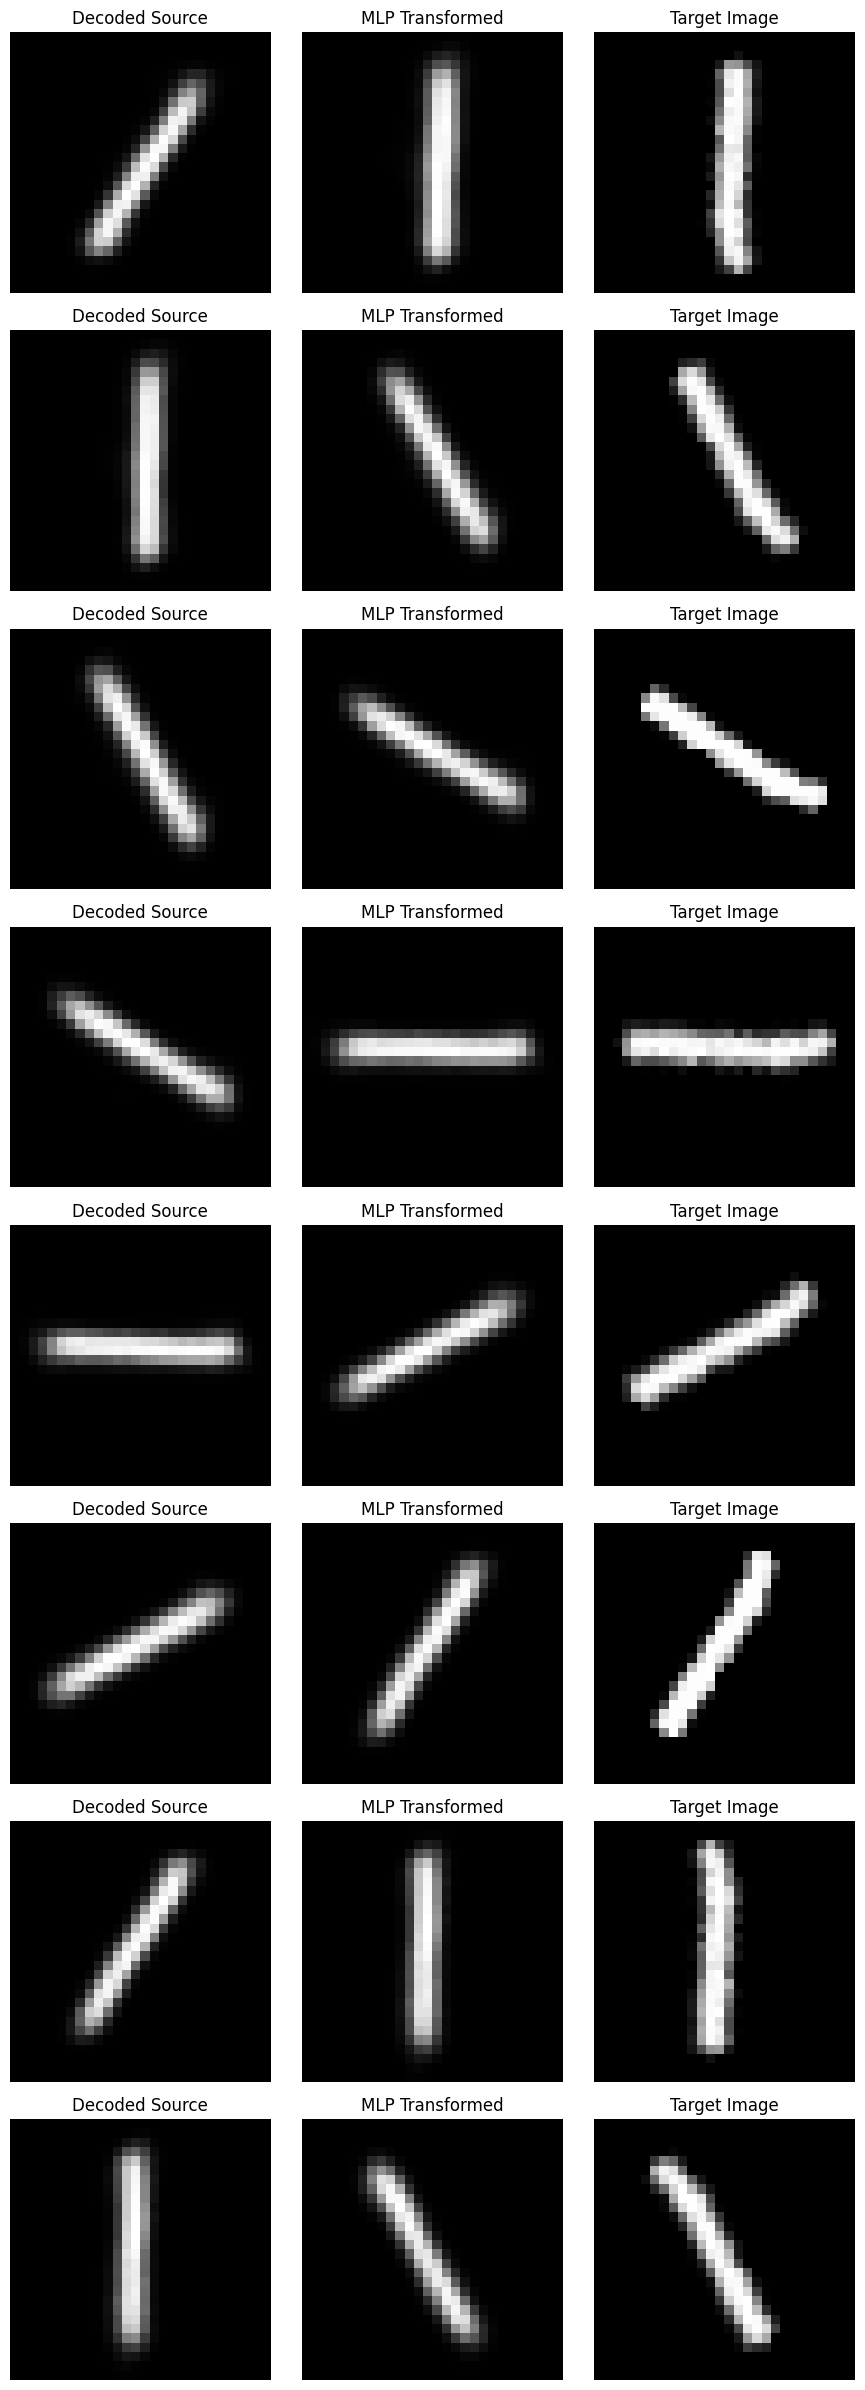

In [21]:
model.eval()
mlp.eval()
with torch.no_grad():
    for img_source, img_target, source_angle, label in mlp_val_dataloader:
        img_source = img_source.to(device).float() / 255.0
        img_target = img_target.to(device).float() / 255.0

        _, z, _ = model(img_source)

        z_transformed = mlp(z)

        h_decode_source = model.fc_decode(z)
        decoded_source = model.decoder(h_decode_source)

        h_decode_transformed = model.fc_decode(z_transformed)
        decoded_transformed = model.decoder(h_decode_transformed)

        batch_size = img_source.size(0)
        n = min(8, batch_size) 
        fig, axes = plt.subplots(n, 3, figsize=(9, n * 3))
        for i in range(n):
            axes[i, 0].imshow(decoded_source[i].cpu().squeeze(), cmap='gray')
            axes[i, 0].set_title("Decoded Source")
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(decoded_transformed[i].cpu().squeeze(), cmap='gray')
            axes[i, 1].set_title("MLP Transformed")
            axes[i, 1].axis('off')
            axes[i, 2].imshow(img_target[i].cpu().squeeze(), cmap='gray')
            axes[i, 2].set_title("Target Image")
            axes[i, 2].axis('off')
        
        plt.tight_layout()
        plt.show()
        break